# 01 — Exploratory Data Analysis (variable by variable)

**Course:** Machine Learning and Deep Learning (CBS, Spring 2026)
**Companion to:** `gameplan.md`

This notebook walks through every variable in the ESS11 selection, **one at a time**.

For each variable you'll see:

1. What the variable measures (codebook description).
2. Raw value counts, including ESS sentinel codes (66 / 77 / 88 / 99 etc.).
3. A distribution plot.
4. A bivariate plot: turnout rate by variable value.
5. A clear **cleaning decision** and any planned transformation.

At the end the notebook builds two parallel feature sets that the modeling notebook (`03_modeling_andreja.ipynb`) will train on:

- **Set A (raw, ~24 features)** — every variable kept individually.
- **Set B (composite, ~11 features)** — `trust_index`, `efficacy_index`, `satisfaction_index` replace their components.

That way, performance and interpretability are both respected and we let the data decide the trade-off.


## 0. Setup
Imports, fixed seed, plotting style.


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = 'ESS11e04_1.csv'
TARGET = 'vote'
print('Setup complete.')


Setup complete.


## 1. Load the raw data

We load only the 25 columns that matter for this project (24 features + target + 2 design weights).
The weights are kept for descriptive statistics but are **not** used as model features.


In [50]:
USECOLS = [
    'vote',
    # 1. socio-demographic
    'agea', 'gndr', 'cntry',
    # 2. socio-economic
    'eduyrs', 'hinctnta',
    # 3. political interest & ideology
    'polintr', 'lrscale', 'clsprty',
    # 4. institutional trust
    'trstprl', 'trstplt', 'trstprt', 'trstlgl',
    # 5. civic & political engagement
    'contplt', 'sgnptit', 'cptppola', 'psppsgva', 'psppipla',
    # 6. satisfaction with system
    'stfdem', 'stfgov', 'stfeco',
    # 7. media & information
    'nwspol', 'netusoft',
    # weights (descriptive only)
    'pspwght', 'anweight',
]

df = pd.read_csv(DATA_PATH, usecols=USECOLS)
print(f'Shape: {df.shape}')
print(f'Countries ({df.cntry.nunique()}): {sorted(df.cntry.unique())}')
df.head()


Shape: (50116, 25)
Countries (30): ['AT', 'BE', 'BG', 'CH', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK', 'UA']


,cntry,pspwght,anweight,nwspol,netusoft,polintr,psppsgva,psppipla,cptppola,trstprl,...,sgnptit,clsprty,lrscale,stfeco,stfgov,stfdem,gndr,agea,eduyrs,hinctnta
0,AT,0.392891,0.130013,90,5,1,4,4,5,6,...,2,1,5,6,4,6,1,65,12,6
1,AT,0.325153,0.107598,90,5,2,3,3,2,6,...,1,1,0,2,5,7,2,21,14,1
2,AT,4.000023,1.323666,30,5,2,4,4,3,7,...,1,1,3,6,5,6,2,53,16,5
3,AT,0.176228,0.058316,15,1,3,2,2,3,5,...,2,2,5,4,4,6,2,78,14,2
4,AT,1.060940,0.351080,60,5,2,3,4,3,6,...,1,1,2,6,7,8,1,64,12,77


## 2. Target variable: `vote`

ESS question: *"Did you vote in the last [country] national election?"*

Coded values:
- `1` = Yes
- `2` = No
- `3` = Not eligible to vote
- `7` = Refusal
- `8` = Don't know
- `9` = No answer

**Cleaning rules:**
- Drop `3` (different population — non-citizens, too young).
- Drop `7 / 8 / 9` (non-response — uninformative).
- Recode `1 → 1`, `2 → 0`. Final binary target = `voted`.


In [51]:
vote_labels = {1: 'Yes', 2: 'No', 3: 'Not eligible',
                7: 'Refusal', 8: "Don't know", 9: 'No answer'}

raw = df['vote'].value_counts().sort_index()
pct = df['vote'].value_counts(normalize=True).sort_index() * 100
overview = pd.DataFrame({'count': raw, 'pct': pct.round(2)})
overview.index = [f'{int(i)} - {vote_labels.get(int(i), "?")}' for i in overview.index]
print(f'Raw target distribution (BEFORE filter, N = {len(df):,}):')
print(overview)

# Apply cleaning - from this point on `df` ONLY contains vote-eligible respondents
n_before = len(df)
df = df[df['vote'].isin([1, 2])].copy()
df['vote'] = (df['vote'] == 1).astype(int)
n_after = len(df)

print()
print('=' * 64)
print(f'  WORKING SAMPLE: df now has N = {n_after:,} rows')
print(f'  (dropped {n_before - n_after:,} rows: ineligible + non-response)')
print(f'  Every variable analysis below uses this filtered sample.')
print('=' * 64)
print(f'\nClass balance: voted = {df.vote.mean()*100:.1f}%, '
      f'did not vote = {(1-df.vote.mean())*100:.1f}%')

# Constant the helpers will reference
WORKING_N = n_after


Raw target distribution (BEFORE filter, N = 50,116):
                  count    pct
1 - Yes           36293  72.42
2 - No            10177  20.31
3 - Not eligible   3151   6.29
7 - Refusal         227   0.45
8 - Don't know      246   0.49
9 - No answer        22   0.04

  WORKING SAMPLE: df now has N = 46,470 rows
  (dropped 3,646 rows: ineligible + non-response)
  Every variable analysis below uses this filtered sample.

Class balance: voted = 78.1%, did not vote = 21.9%


## 3. Helper functions for variable-by-variable EDA

To keep the per-variable code short and readable, two small helpers do all the work:

- `analyze_numeric(col, sentinels, title=None)` — for ordinal/numeric variables. Shows distribution + turnout rate by value.
- `analyze_categorical(col, labels=None)` — for categorical / binary variables.

Each call produces a 1×2 figure: distribution on the left, turnout rate on the right.


In [52]:
def analyze_numeric(col, sentinels=None, title=None):
    """Two-panel EDA for an ordinal/numeric variable.

    Operates on the filtered df (vote-eligible respondents only).
    Prints N explicitly so the denominator is always visible.
    """
    sentinels = sentinels or []
    s = df[col]
    N = len(s)

    print(f'--- {col} ---')
    print(f'Working sample: N = {N:,} (vote-eligible respondents only)')

    if sentinels:
        sent_n = {v: int((s == v).sum()) for v in sentinels}
        print(f'Sentinel codes:')
        for v in sentinels:
            n = sent_n[v]
            print(f'  {v:>5} -> n = {n:>5} ({100*n/N:.2f}% of {N:,})')

    valid = s[~s.isin(sentinels)]
    print(f'Valid (non-sentinel): n = {len(valid):,} '
          f'({100*len(valid)/N:.2f}% of {N:,})')
    print(f'  mean = {valid.mean():.2f}, median = {valid.median():.1f}, '
          f'sd = {valid.std():.2f}')

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    axes[0].hist(valid, bins=min(30, valid.nunique()),
                 color='#5b9bd5', edgecolor='white')
    axes[0].set_title(f'{col} - distribution (n={len(valid):,}, sentinels excluded)')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('count')

    tmp = df[~df[col].isin(sentinels)].groupby(col)['vote'].agg(['mean', 'count'])
    axes[1].bar(tmp.index, tmp['mean'] * 100, color='#5cb85c', edgecolor='white')
    axes[1].axhline(df['vote'].mean() * 100, color='#d9534f', ls='--',
                    label=f'overall = {df.vote.mean()*100:.1f}% (N={N:,})')
    axes[1].set_title(f'turnout rate by {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('% voted')
    axes[1].legend()

    plt.suptitle(title or f'{col}  (working N = {N:,})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return valid


def analyze_categorical(col, labels=None, sentinels=None):
    """Two-panel EDA for a categorical/binary variable.

    Operates on the filtered df (vote-eligible respondents only).
    Prints N explicitly so the denominator is always visible.
    """
    sentinels = sentinels or []
    s = df[col]
    N = len(s)

    print(f'--- {col} ---')
    print(f'Working sample: N = {N:,} (vote-eligible respondents only)')

    counts = s.value_counts(dropna=False).sort_index()
    print(f'Value counts:')
    for v, n in counts.items():
        lab = labels.get(v, '') if labels else ''
        sentinel_flag = '  [sentinel]' if v in sentinels else ''
        print(f'  {v} {lab:<20} n = {n:>6}  ({100*n/N:.2f}% of {N:,}){sentinel_flag}')

    valid = df[~df[col].isin(sentinels)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    counts_valid = valid[col].value_counts().sort_index()
    xlabels = [f'{v}\n{labels[v]}' if labels and v in labels else str(v)
               for v in counts_valid.index]
    axes[0].bar(xlabels, counts_valid.values, color='#5b9bd5', edgecolor='white')
    axes[0].set_title(f'{col} - distribution (n={len(valid):,})')
    axes[0].set_ylabel('count')

    tmp = valid.groupby(col)['vote'].mean() * 100
    xlabels = [f'{v}\n{labels[v]}' if labels and v in labels else str(v)
               for v in tmp.index]
    axes[1].bar(xlabels, tmp.values, color='#5cb85c', edgecolor='white')
    axes[1].axhline(df['vote'].mean() * 100, color='#d9534f', ls='--',
                    label=f'overall = {df.vote.mean()*100:.1f}% (N={N:,})')
    axes[1].set_title(f'turnout rate by {col}')
    axes[1].set_ylabel('% voted')
    axes[1].legend()

    plt.suptitle(f'{col}  (working N = {N:,})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 4. Category 1 — Socio-demographic

> **Reminder:** every analysis below operates on the filtered `df` of **N = 46,470 vote-eligible respondents** (not the original 50,116). The helpers print this N at the top of every variable's output, and the percentages are always computed on this denominator.

Variables: `agea`, `gndr`, `cntry`.

Theoretical role: baseline controls. Turnout has well-documented age and (sometimes) gender gradients, and varies systematically across countries.


### 4.1 `agea` — age in years

- **Type:** continuous
- **Sentinels:** `999` = Not available
- **Expected:** strong positive relationship with turnout (older respondents vote more — well-documented)


--- agea ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
    999 -> n =   354 (0.76% of 46,470)
Valid (non-sentinel): n = 46,116 (99.24% of 46,470)
  mean = 53.05, median = 54.0, sd = 17.86


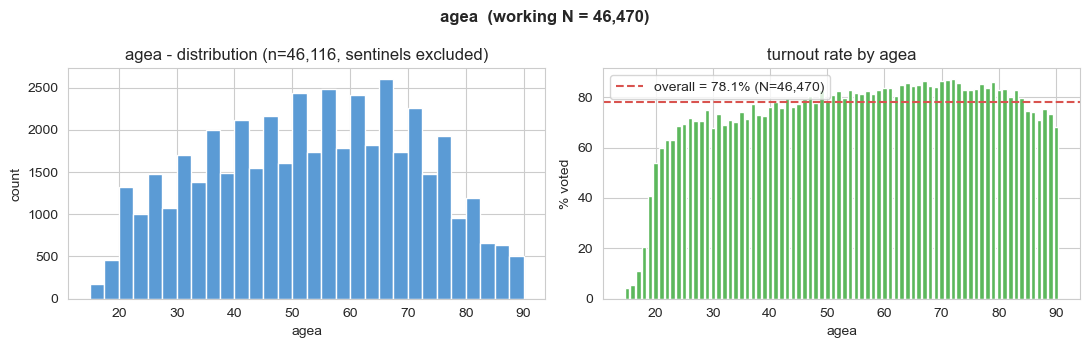

In [53]:
_ = analyze_numeric('agea', sentinels=[999])


**Decision:**
- Drop sentinel `999`, then median-impute (rare).
- **Keep raw `agea`** for modeling — trees and NN handle non-linearity natively.
- **Add `age_group`** (categorical) for plotting and reporting tables: {18–24, 25–34, 35–49, 50–64, 65+}.


In [87]:
# Build age_group for EDA / reporting only (not a model feature)
df['age_group'] = pd.cut(df['agea'].replace(999, np.nan),
                         bins=[0, 29, 49, 64, 120],
                         labels=['18-29', '30-49', '50-64', '65+'])

age_grp_turnout = df.groupby('age_group')['vote'].agg(['mean', 'count'])
age_grp_turnout['mean'] = (age_grp_turnout['mean'] * 100).round(1)
age_grp_turnout.columns = ['turnout %', 'n']
print('Turnout by age group:')
print(age_grp_turnout)


Turnout by age group:
           turnout %      n
age_group                  
18-29           62.5   5494
30-49           75.3  14017
50-64           82.1  12671
65+             83.5  13934


### 4.2 `gndr` — gender

- **Type:** categorical
- **Codes:** `1` = Male, `2` = Female, `9` = No answer


--- gndr ---
Working sample: N = 46,470 (vote-eligible respondents only)
Value counts:
  1 Male                 n =  21310  (45.86% of 46,470)
  2 Female               n =  25160  (54.14% of 46,470)


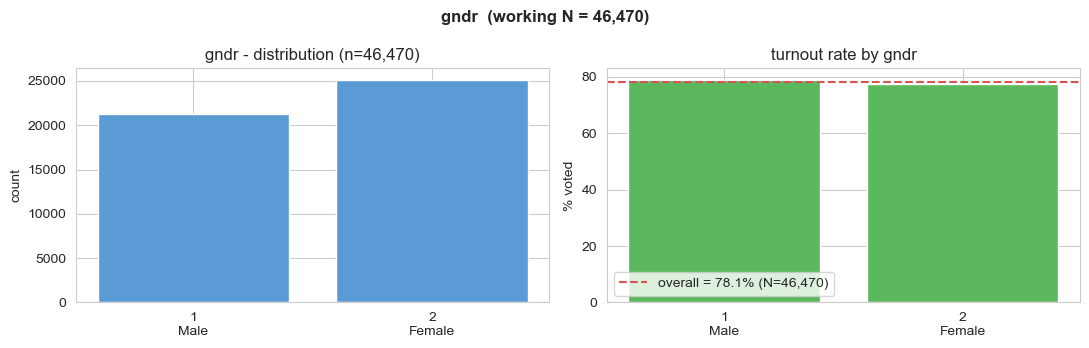

In [88]:
_ = analyze_categorical('gndr', labels={1: 'Male', 2: 'Female', 9: 'No answer'},
                        sentinels=[9])


**Decision:**
- Drop `9` (vanishingly rare).
- Recode `1 → 1` (Male), `2 → 0` (Female).
- Use directly in models.


### 4.3 `cntry` — country (30 levels)

Categorical with no missingness. Strong predictor — turnout varies a lot by country.


Number of countries: 30

Turnout rate by country (sorted):
       turnout %     n
cntry                 
FR          62.4  1593
LT          65.2  1292
CH          66.4  1070
BG          67.3  2126
UA          67.8  2536
IT          69.2  2590
LV          73.5  1152
GB          73.6  1571
EE          74.1  1175
PT          74.6  1292
HR          74.7  1443
CY          76.5   634
IL          77.6   839
HU          77.9  2033
ME          78.7  1552
ES          78.8  1651
SK          79.3  1408
RS          79.9  1484
AT          80.8  2189
IE          81.3  1867
SI          82.5  1157
GR          83.3  2695
NL          86.3  1555
PL          86.3  1366
FI          86.6  1495
BE          87.0  1403
DE          88.2  2160
NO          90.5  1199
IS          91.7   758
SE          95.7  1185


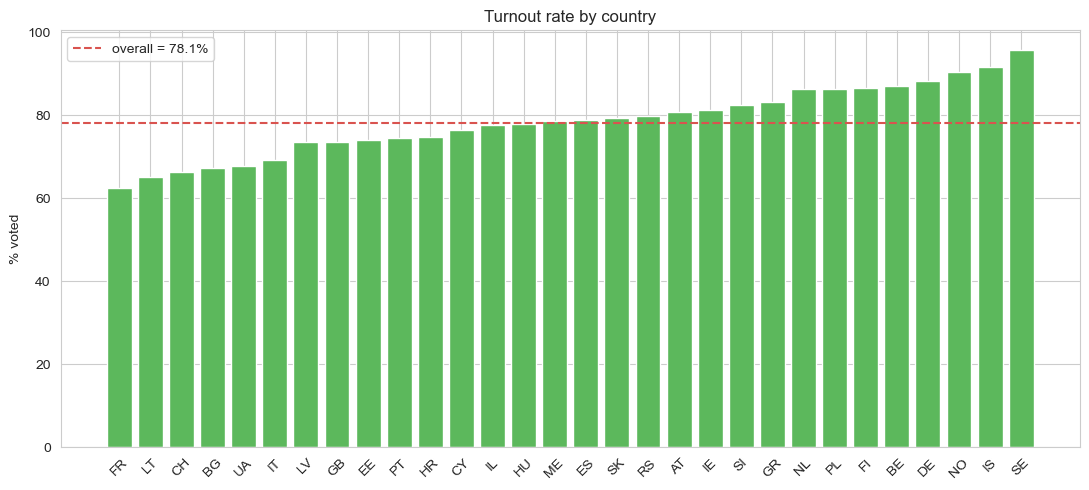

In [56]:
print(f'Number of countries: {df.cntry.nunique()}')
turnout_by_country = df.groupby('cntry')['vote'].agg(['mean', 'count']).sort_values('mean')
turnout_by_country['mean'] = (turnout_by_country['mean'] * 100).round(1)
turnout_by_country.columns = ['turnout %', 'n']
print('\nTurnout rate by country (sorted):')
print(turnout_by_country)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(turnout_by_country.index, turnout_by_country['turnout %'],
       color='#5cb85c', edgecolor='white')
ax.axhline(df['vote'].mean() * 100, color='#d9534f', ls='--',
           label=f'overall = {df.vote.mean()*100:.1f}%')
ax.set_title('Turnout rate by country')
ax.set_ylabel('% voted')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Decision:**
- Keep as-is (no sentinels).
- Encoding: one-hot (drop_first=True) for LR / NN; ordinal or target encoding for trees.


## 5. Category 2 — Socio-economic resources

Variables: `eduyrs`, `hinctnta`.

Theoretical role: the "resources" pillar of the Civic Voluntarism Model. Education and income predict participation through political knowledge, civic skills, and networks.


### 5.1 `eduyrs` — years of full-time education

- **Type:** continuous
- **Sentinels:** `77 / 88 / 99` = Refusal / DK / No answer


In [89]:
df['eduyrs'].describe()

count    46470.000000
mean        14.588702
std         10.279215
min          0.000000
25%         11.000000
50%         13.000000
75%         16.000000
max         99.000000
Name: eduyrs, dtype: float64

--- eduyrs ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =   221 (0.48% of 46,470)
     88 -> n =   559 (1.20% of 46,470)
     99 -> n =    31 (0.07% of 46,470)
Valid (non-sentinel): n = 45,659 (98.25% of 46,470)
  mean = 13.33, median = 13.0, sd = 4.04


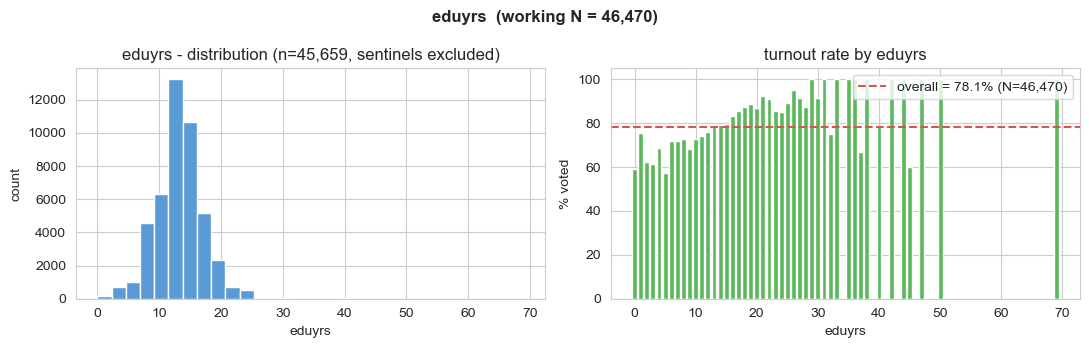

In [57]:
_ = analyze_numeric('eduyrs', sentinels=[77, 88, 99])


**Decision:**
- Replace sentinels with NaN, median-impute.
- Cap at 99th percentile to handle data-entry outliers.
- **Add `edu_level`** for plotting: low (≤9), medium (10–14), high (≥15).
- Keep raw `eduyrs` for the model.


In [90]:
ey = df['eduyrs'].replace([77, 88, 99], np.nan)
df['edu_level'] = pd.cut(ey, bins=[-0.1, 9, 14, 100],
                         labels=['low (<=9)', 'medium (10-14)', 'high (>=15)'])
edu_turnout = df.groupby('edu_level')['vote'].agg(['mean', 'count'])
edu_turnout['mean'] = (edu_turnout['mean'] * 100).round(1)
edu_turnout.columns = ['turnout %', 'n']
print(edu_turnout)


                turnout %      n
edu_level                       
low (<=9)            69.6   6475
medium (10-14)       76.3  22804
high (>=15)          84.8  16380


### 5.2 `hinctnta` — household income decile (1–10)

- **Type:** ordinal (already binned by ESS into deciles)
- **Sentinels:** `77 / 88 / 99`
- **Note:** this variable typically has a non-trivial DK/Refusal rate (income is sensitive)


--- hinctnta ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =  6827 (14.69% of 46,470)
     88 -> n =  2336 (5.03% of 46,470)
     99 -> n =    35 (0.08% of 46,470)
Valid (non-sentinel): n = 37,272 (80.21% of 46,470)
  mean = 5.40, median = 5.0, sd = 2.75


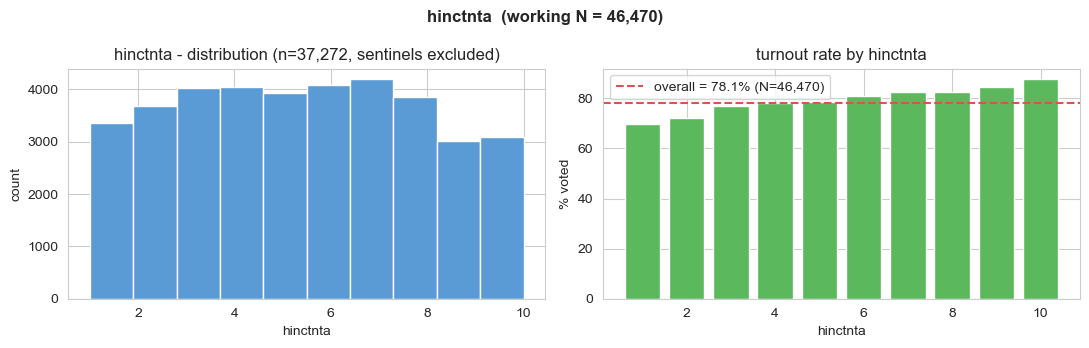

In [91]:
_ = analyze_numeric('hinctnta', sentinels=[77, 88, 99])


**Decision:**
- Replace sentinels with NaN, median-impute (per-country median is even better).
- **Add `income_tertile`** {low (1–3), middle (4–7), high (8–10)} for plots.
- Keep raw 1–10 for the model — already ordinal-scaled.
- Add an `income_was_missing` flag column (high DK rate may itself be informative).


In [60]:
hi = df['hinctnta'].replace([77, 88, 99], np.nan)
df['income_tertile'] = pd.cut(hi, bins=[0, 3, 7, 10],
                              labels=['low (1-3)', 'middle (4-7)', 'high (8-10)'])
inc_turnout = df.groupby('income_tertile')['vote'].agg(['mean', 'count'])
inc_turnout['mean'] = (inc_turnout['mean'] * 100).round(1)
inc_turnout.columns = ['turnout %', 'n']
print(inc_turnout)


                turnout %      n
income_tertile                  
low (1-3)            73.2  11072
middle (4-7)         80.1  16248
high (8-10)          84.7   9952


## 6. Category 3 — Political interest & ideology

Variables: `polintr`, `lrscale`, `clsprty`.


### 6.1 `polintr` — interest in politics

- **Type:** ordinal 1–4
- **Codes:** `1` = Very interested, `2` = Quite interested, `3` = Hardly interested, `4` = Not at all
- **Sentinels:** `7 / 8 / 9`
- **IMPORTANT:** raw scale is *reversed* — lower number = more interest. We'll flip it so higher = more interest.


--- polintr ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
      7 -> n =    31 (0.07% of 46,470)
      8 -> n =    38 (0.08% of 46,470)
      9 -> n =     5 (0.01% of 46,470)
Valid (non-sentinel): n = 46,396 (99.84% of 46,470)
  mean = 2.63, median = 3.0, sd = 0.93


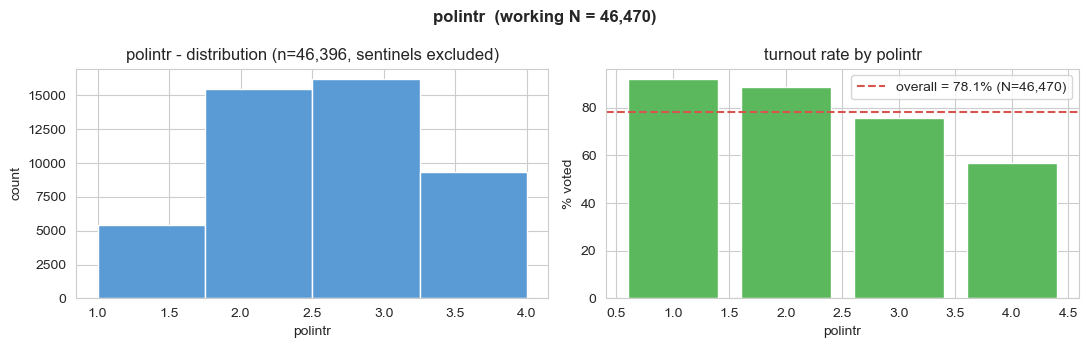

In [61]:
_ = analyze_numeric('polintr', sentinels=[7, 8, 9])


**Decision:**
- Replace sentinels with NaN, median-impute.
- **Reverse-code** so higher = more interest (`5 - polintr`).


### 6.2 `lrscale` — left-right self-placement (0=left ... 10=right)

- **Type:** ordinal 0–10
- **Sentinels:** `77 / 88 / 99`
- **Hypothesis:** turnout is U-shaped — extremists on both ends vote more than centrists.


--- lrscale ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =  1831 (3.94% of 46,470)
     88 -> n =  4614 (9.93% of 46,470)
     99 -> n =    25 (0.05% of 46,470)
Valid (non-sentinel): n = 40,000 (86.08% of 46,470)
  mean = 5.08, median = 5.0, sd = 2.29


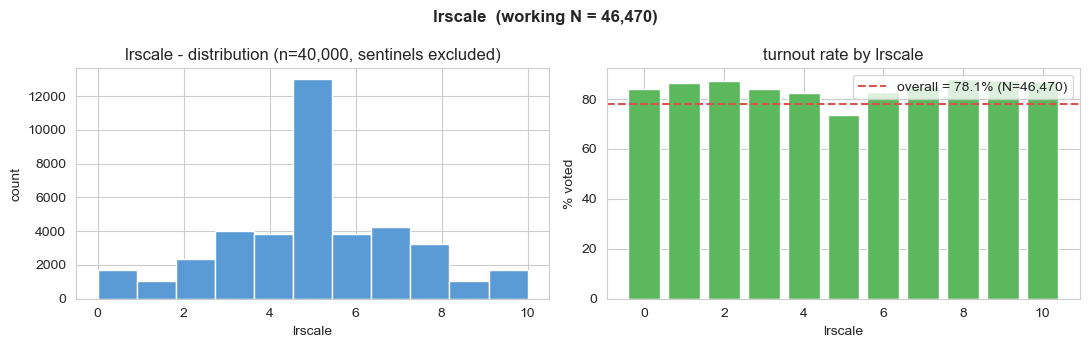

In [62]:
_ = analyze_numeric('lrscale', sentinels=[77, 88, 99])


**Decision:**
- Replace sentinels with NaN, median-impute.
- Keep raw `lrscale`.
- **Add `lr_extreme = abs(lrscale - 5)`** as a second feature — captures distance from the centre, often a stronger predictor than raw left-right.


### 6.3 `clsprty` — feels close to a particular political party

- **Type:** binary
- **Codes:** `1` = Yes, `2` = No, `7 / 8 / 9` = sentinels


--- clsprty ---
Working sample: N = 46,470 (vote-eligible respondents only)
Value counts:
  1 Yes                  n =  20138  (43.34% of 46,470)
  2 No                   n =  25172  (54.17% of 46,470)
  7 Refusal              n =    430  (0.93% of 46,470)  [sentinel]
  8 DK                   n =    723  (1.56% of 46,470)  [sentinel]
  9 NA                   n =      7  (0.02% of 46,470)  [sentinel]


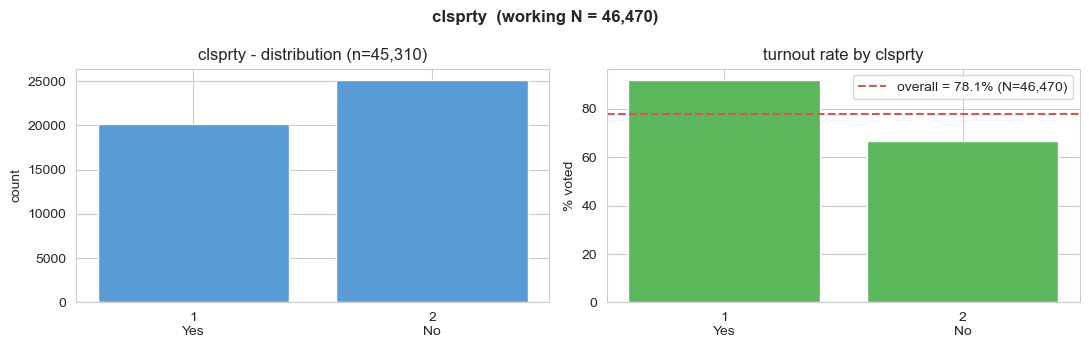

In [63]:
_ = analyze_categorical('clsprty',
                        labels={1: 'Yes', 2: 'No', 7: 'Refusal', 8: "DK", 9: 'NA'},
                        sentinels=[7, 8, 9])


**Decision:**
- Replace sentinels with NaN, mode-impute.
- Recode `1 → 1` (yes), `2 → 0` (no).


## 7. Category 4 — Institutional trust

Variables: `trstprl` (parliament), `trstplt` (politicians), `trstprt` (parties), `trstlgl` (legal system).

All four use the same 0–10 scale. **They typically correlate at r ≈ 0.7–0.8** — perfect candidates for a composite index.


In [64]:
trust_vars = ['trstprl', 'trstplt', 'trstprt', 'trstlgl']
trust_sentinels = [77, 88, 99]

# Quick value-counts table for all 4 trust variables
for v in trust_vars:
    sent_n = sum((df[v] == s).sum() for s in trust_sentinels)
    print(f'  {v}: sentinels = {sent_n} ({100*sent_n/len(df):.2f}%)')


  trstprl: sentinels = 704 (1.51%)
  trstplt: sentinels = 553 (1.19%)
  trstprt: sentinels = 680 (1.46%)
  trstlgl: sentinels = 919 (1.98%)


### 7.1–7.4 The four trust variables (treated together)

--- trstprl ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =    89 (0.19% of 46,470)
     88 -> n =   612 (1.32% of 46,470)
     99 -> n =     3 (0.01% of 46,470)
Valid (non-sentinel): n = 45,766 (98.49% of 46,470)
  mean = 4.27, median = 5.0, sd = 2.71


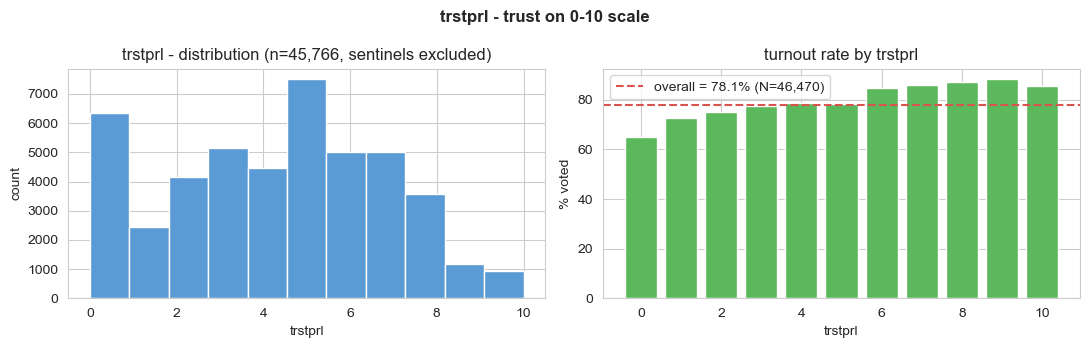

--- trstplt ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =   101 (0.22% of 46,470)
     88 -> n =   446 (0.96% of 46,470)
     99 -> n =     6 (0.01% of 46,470)
Valid (non-sentinel): n = 45,917 (98.81% of 46,470)
  mean = 3.48, median = 3.0, sd = 2.49


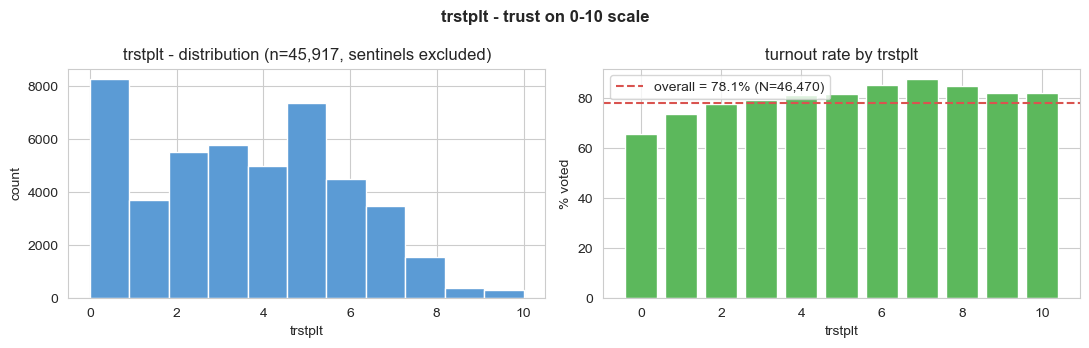

--- trstprt ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =    94 (0.20% of 46,470)
     88 -> n =   581 (1.25% of 46,470)
     99 -> n =     5 (0.01% of 46,470)
Valid (non-sentinel): n = 45,790 (98.54% of 46,470)
  mean = 3.45, median = 3.0, sd = 2.45


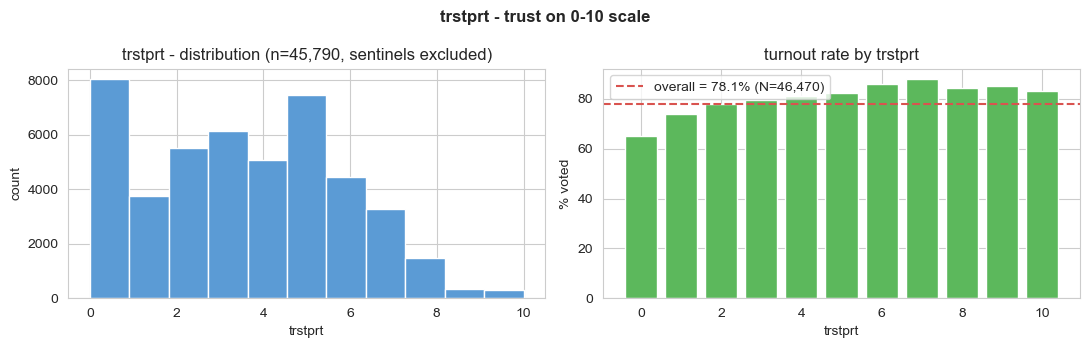

--- trstlgl ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =    80 (0.17% of 46,470)
     88 -> n =   831 (1.79% of 46,470)
     99 -> n =     8 (0.02% of 46,470)
Valid (non-sentinel): n = 45,551 (98.02% of 46,470)
  mean = 5.21, median = 5.0, sd = 2.76


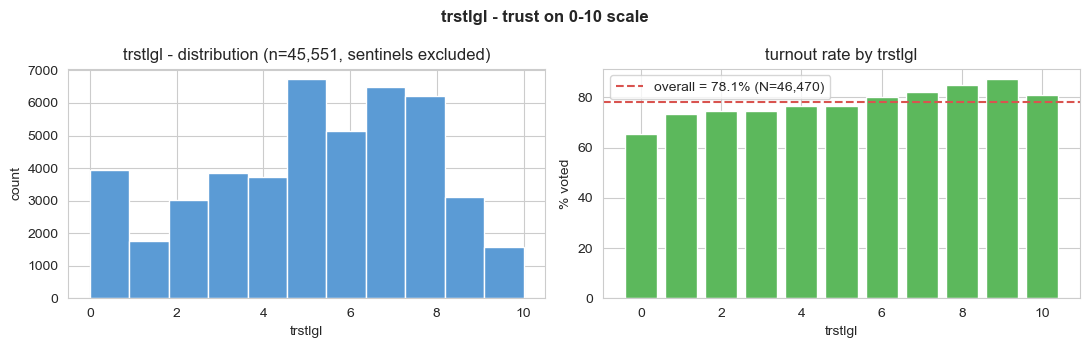

In [65]:
for v in trust_vars:
    _ = analyze_numeric(v, sentinels=trust_sentinels, title=f'{v} - trust on 0-10 scale')


### 7.5 Correlation among trust variables

If they are highly correlated, combining them into one index is justified.


Spearman correlations among trust variables:
         trstprl  trstplt  trstprt  trstlgl
trstprl     1.00     0.75     0.73     0.65
trstplt     0.75     1.00     0.88     0.59
trstprt     0.73     0.88     1.00     0.57
trstlgl     0.65     0.59     0.57     1.00


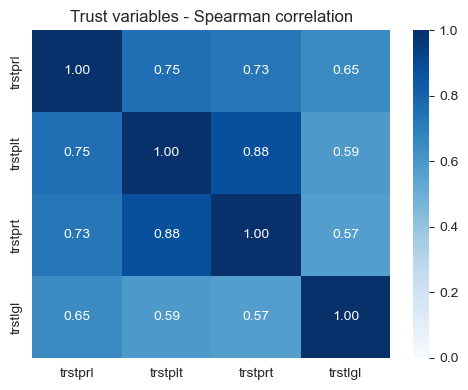

In [66]:
trust_clean = df[trust_vars].replace(trust_sentinels, np.nan)
corr = trust_clean.corr(method='spearman')
print('Spearman correlations among trust variables:')
print(corr.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title('Trust variables - Spearman correlation')
plt.tight_layout()
plt.show()


**Decision:**
- Replace sentinels, median-impute.
- **Set A (raw):** keep all four individually.
- **Set B (composite):** create `trust_index = mean(trstprl, trstplt, trstprt, trstlgl)` and drop the four originals.
- The modeling notebook compares both.


## 8. Category 5 — Civic & political engagement

Variables: `contplt`, `sgnptit`, `cptppola`, `psppsgva`, `psppipla`.

This category mixes **behaviour** (`contplt`, `sgnptit`) and **efficacy** (`cptppola`, `psppsgva`, `psppipla`).


### 8.1 `contplt` — contacted politician/government official (last 12 mo.)

Binary. Sentinels `7 / 8 / 9`.


--- contplt ---
Working sample: N = 46,470 (vote-eligible respondents only)
Value counts:
  1 Yes                  n =   6926  (14.90% of 46,470)
  2 No                   n =  39303  (84.58% of 46,470)
  7 Ref                  n =    141  (0.30% of 46,470)  [sentinel]
  8 DK                   n =     95  (0.20% of 46,470)  [sentinel]
  9 NA                   n =      5  (0.01% of 46,470)  [sentinel]


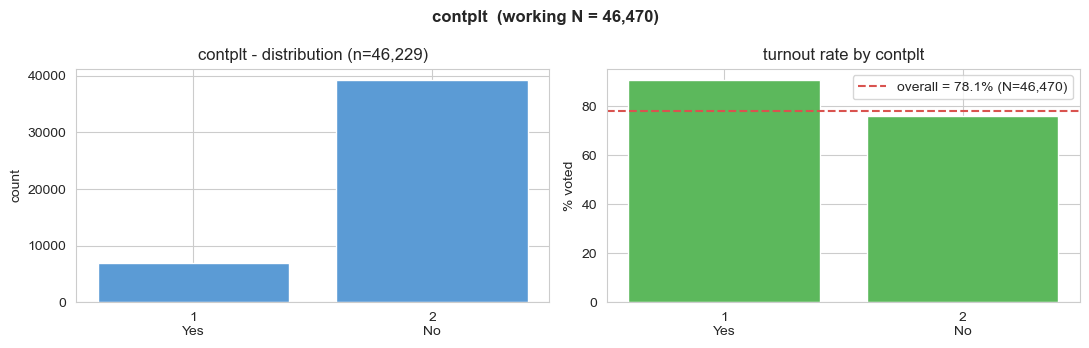

In [67]:
_ = analyze_categorical('contplt', labels={1: 'Yes', 2: 'No', 7: 'Ref', 8: 'DK', 9: 'NA'},
                        sentinels=[7, 8, 9])


### 8.2 `sgnptit` — signed a petition (last 12 mo.)

Binary. Sentinels `7 / 8 / 9`.


--- sgnptit ---
Working sample: N = 46,470 (vote-eligible respondents only)
Value counts:
  1 Yes                  n =   9215  (19.83% of 46,470)
  2 No                   n =  37023  (79.67% of 46,470)
  7 Ref                  n =     90  (0.19% of 46,470)  [sentinel]
  8 DK                   n =    135  (0.29% of 46,470)  [sentinel]
  9 NA                   n =      7  (0.02% of 46,470)  [sentinel]


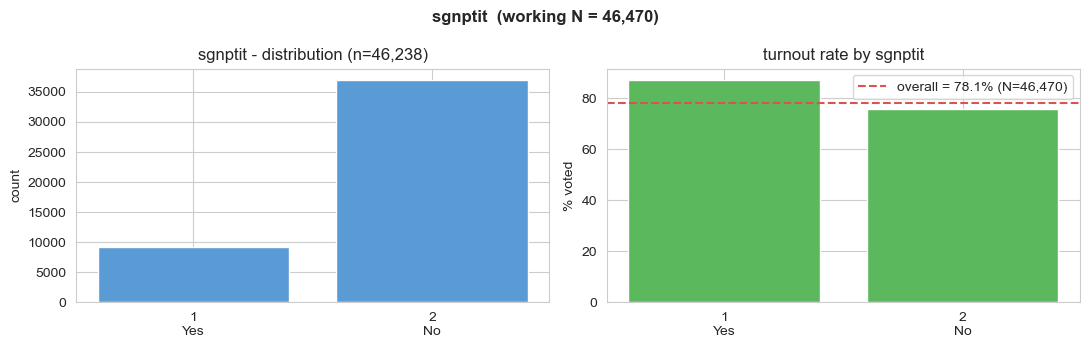

In [68]:
_ = analyze_categorical('sgnptit', labels={1: 'Yes', 2: 'No', 7: 'Ref', 8: 'DK', 9: 'NA'},
                        sentinels=[7, 8, 9])


**Decision (behavioural binaries):** replace sentinels → NaN, mode-impute, recode `1→1`, `2→0`.

### 8.3 `cptppola` — confident in own ability to participate in politics

Ordinal 1–5. Sentinels `7 / 8 / 9`.


--- cptppola ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
      7 -> n =   113 (0.24% of 46,470)
      8 -> n =   700 (1.51% of 46,470)
      9 -> n =     6 (0.01% of 46,470)
Valid (non-sentinel): n = 45,651 (98.24% of 46,470)
  mean = 2.15, median = 2.0, sd = 1.08


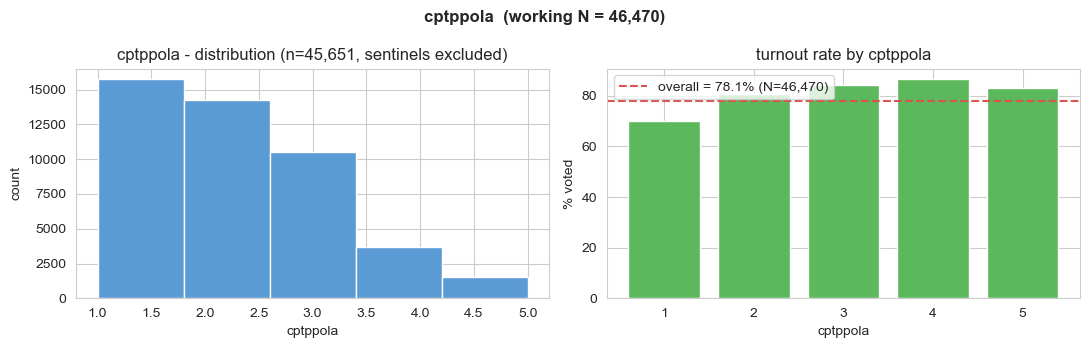

In [69]:
_ = analyze_numeric('cptppola', sentinels=[7, 8, 9])


### 8.4 `psppsgva` — political system allows people to have a say

Ordinal 1–5. Sentinels `7 / 8 / 9`.


--- psppsgva ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
      7 -> n =    74 (0.16% of 46,470)
      8 -> n =   716 (1.54% of 46,470)
      9 -> n =    23 (0.05% of 46,470)
Valid (non-sentinel): n = 45,657 (98.25% of 46,470)
  mean = 2.16, median = 2.0, sd = 0.98


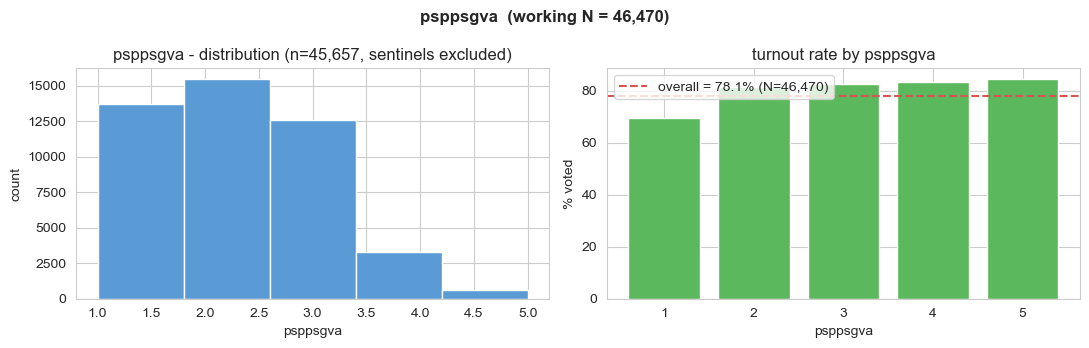

In [70]:
_ = analyze_numeric('psppsgva', sentinels=[7, 8, 9])


### 8.5 `psppipla` — political system allows people to influence

Ordinal 1–5. Sentinels `7 / 8 / 9`.


--- psppipla ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
      7 -> n =    60 (0.13% of 46,470)
      8 -> n =   661 (1.42% of 46,470)
      9 -> n =    11 (0.02% of 46,470)
Valid (non-sentinel): n = 45,738 (98.42% of 46,470)
  mean = 2.10, median = 2.0, sd = 0.96


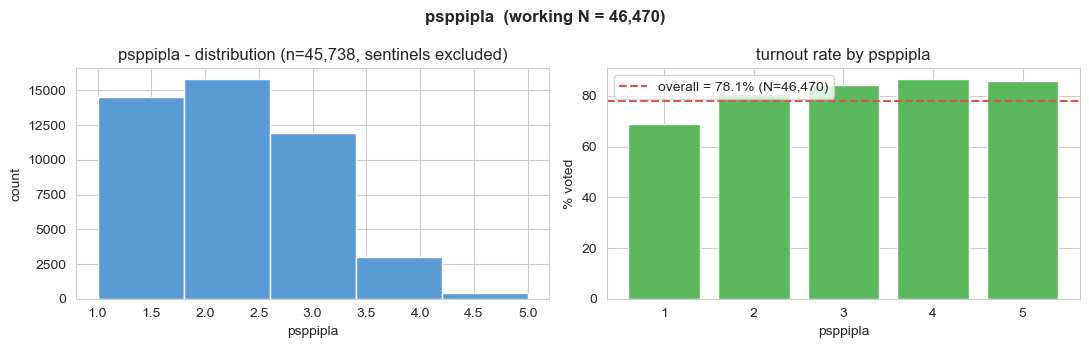

In [71]:
_ = analyze_numeric('psppipla', sentinels=[7, 8, 9])


### 8.6 Correlation among the three efficacy items

          cptppola  psppsgva  psppipla
cptppola      1.00      0.38      0.46
psppsgva      0.38      1.00      0.68
psppipla      0.46      0.68      1.00


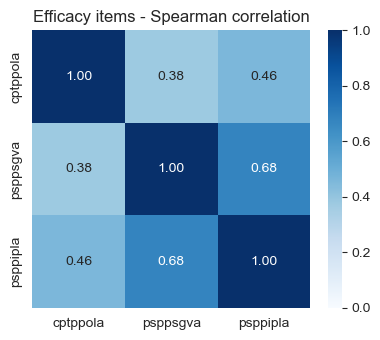

In [72]:
eff_vars = ['cptppola', 'psppsgva', 'psppipla']
eff_clean = df[eff_vars].replace([7, 8, 9], np.nan)
corr = eff_clean.corr(method='spearman')
print(corr.round(2))

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title('Efficacy items - Spearman correlation')
plt.tight_layout()
plt.show()


**Decision:**
- All three: replace sentinels, median-impute.
- **Set A:** keep all three individually.
- **Set B:** create `efficacy_index = mean(cptppola, psppsgva, psppipla)`.


## 9. Category 6 — Satisfaction with system

Variables: `stfdem`, `stfgov`, `stfeco`. All on 0–10 scale, sentinels `77 / 88 / 99`.

**Theoretical note:** satisfaction is conceptually distinct from trust. You can trust an institution without being satisfied with current performance — and vice versa.


### 9.1 `stfdem` — satisfaction with how democracy works

--- stfdem ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =   149 (0.32% of 46,470)
     88 -> n =  1299 (2.80% of 46,470)
     99 -> n =     6 (0.01% of 46,470)
Valid (non-sentinel): n = 45,016 (96.87% of 46,470)
  mean = 4.88, median = 5.0, sd = 2.62


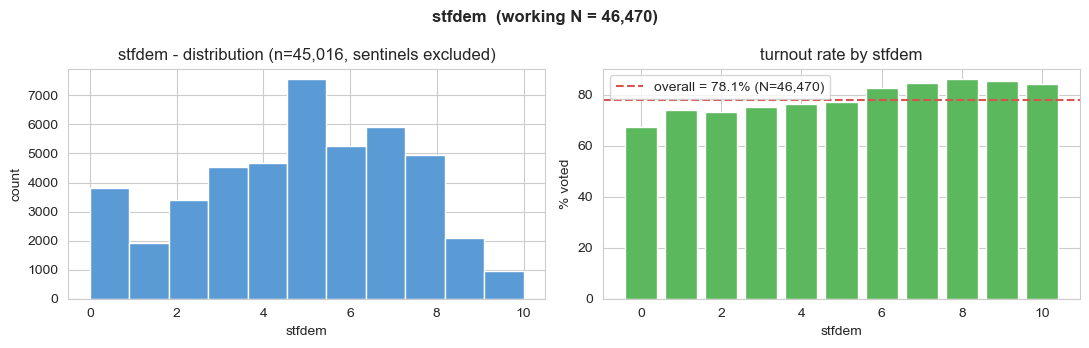

In [73]:
_ = analyze_numeric('stfdem', sentinels=[77, 88, 99])


### 9.2 `stfgov` — satisfaction with national government

--- stfgov ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =   178 (0.38% of 46,470)
     88 -> n =   957 (2.06% of 46,470)
     99 -> n =     6 (0.01% of 46,470)
Valid (non-sentinel): n = 45,329 (97.54% of 46,470)
  mean = 3.93, median = 4.0, sd = 2.55


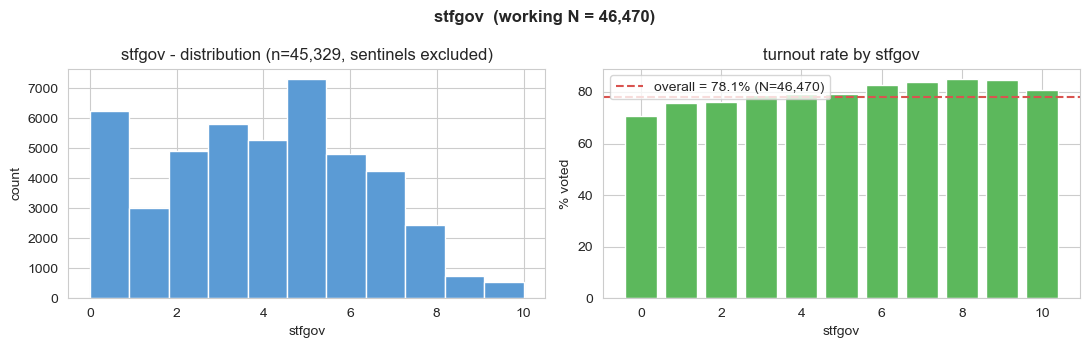

In [74]:
_ = analyze_numeric('stfgov', sentinels=[77, 88, 99])


### 9.3 `stfeco` — satisfaction with state of the economy

--- stfeco ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
     77 -> n =    64 (0.14% of 46,470)
     88 -> n =   629 (1.35% of 46,470)
     99 -> n =     9 (0.02% of 46,470)
Valid (non-sentinel): n = 45,768 (98.49% of 46,470)
  mean = 4.31, median = 4.0, sd = 2.40


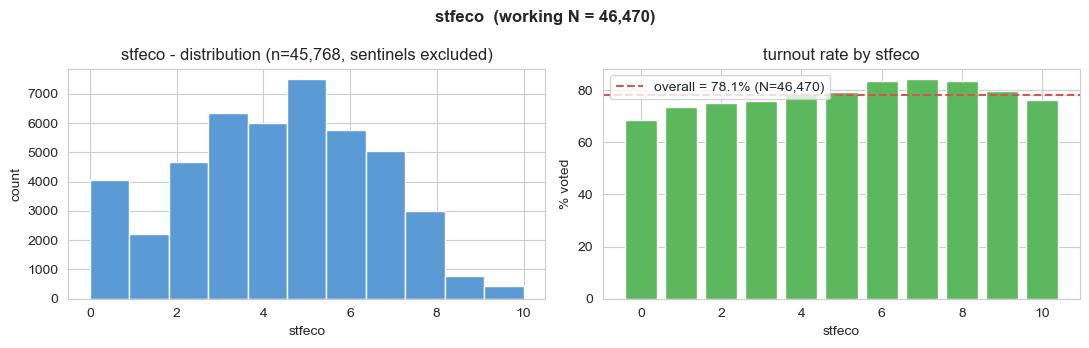

In [75]:
_ = analyze_numeric('stfeco', sentinels=[77, 88, 99])


### 9.4 Correlation among satisfaction items

        stfdem  stfgov  stfeco
stfdem    1.00    0.66    0.60
stfgov    0.66    1.00    0.65
stfeco    0.60    0.65    1.00


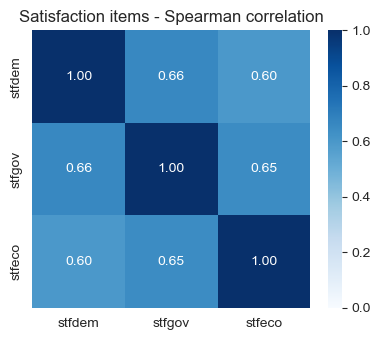

In [76]:
sat_vars = ['stfdem', 'stfgov', 'stfeco']
sat_clean = df[sat_vars].replace([77, 88, 99], np.nan)
corr = sat_clean.corr(method='spearman')
print(corr.round(2))

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title('Satisfaction items - Spearman correlation')
plt.tight_layout()
plt.show()


**Decision:**
- All three: replace sentinels → NaN, median-impute.
- **Set A:** keep all three individually.
- **Set B:** create `satisfaction_index = mean(stfdem, stfgov, stfeco)`.


## 10. Category 7 — Media & information

Variables: `nwspol`, `netusoft`.


### 10.1 `nwspol` — minutes per day spent on news/politics

- **Type:** continuous (minutes)
- **Sentinels:** `6666 / 7777 / 8888 / 9999`
- **Heavy right tail** — a few respondents report 600+ minutes/day. Log-transformation recommended.


--- nwspol ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
   6666 -> n =     0 (0.00% of 46,470)
   7777 -> n =    66 (0.14% of 46,470)
   8888 -> n =   430 (0.93% of 46,470)
   9999 -> n =   173 (0.37% of 46,470)
Valid (non-sentinel): n = 45,801 (98.56% of 46,470)
  mean = 99.29, median = 60.0, sd = 158.25


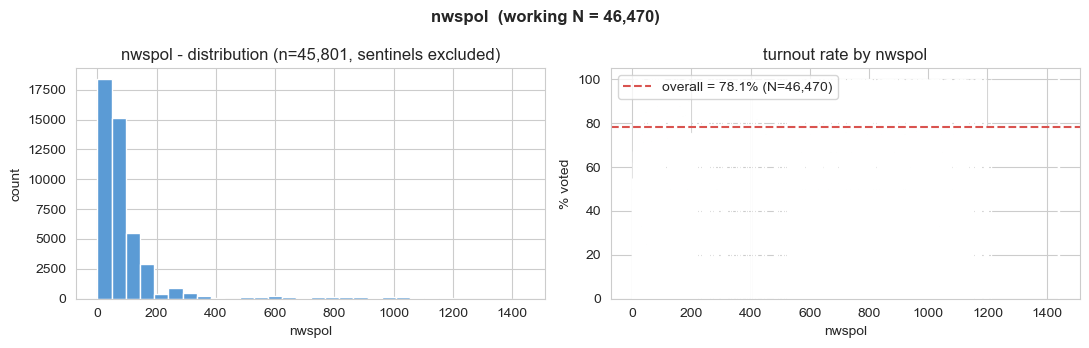

In [77]:
_ = analyze_numeric('nwspol', sentinels=[6666, 7777, 8888, 9999])


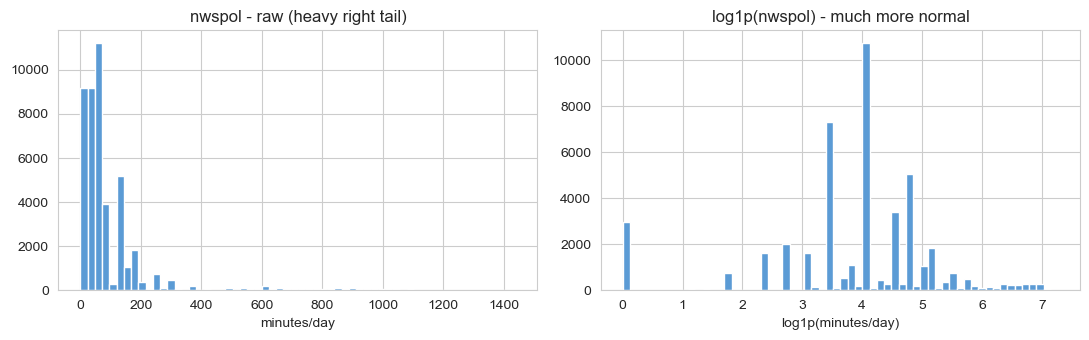

In [78]:
# Distribution after log1p transform
nws_clean = df['nwspol'].replace([6666, 7777, 8888, 9999], np.nan).dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(nws_clean, bins=60, color='#5b9bd5', edgecolor='white')
axes[0].set_title('nwspol - raw (heavy right tail)')
axes[0].set_xlabel('minutes/day')
axes[1].hist(np.log1p(nws_clean), bins=60, color='#5b9bd5', edgecolor='white')
axes[1].set_title('log1p(nwspol) - much more normal')
axes[1].set_xlabel('log1p(minutes/day)')
plt.tight_layout()
plt.show()


**Decision:**
- Replace sentinels, median-impute, **then apply `log1p`**. The transformed version is the model feature.
- Cap raw values at 99th percentile before transform.


### 10.2 `netusoft` — frequency of internet use

- **Type:** ordinal 1–5
- **Codes:** `1` = Never ... `5` = Every day
- **Sentinels:** `7 / 8 / 9`


--- netusoft ---
Working sample: N = 46,470 (vote-eligible respondents only)
Sentinel codes:
      7 -> n =    18 (0.04% of 46,470)
      8 -> n =    17 (0.04% of 46,470)
      9 -> n =    11 (0.02% of 46,470)
Valid (non-sentinel): n = 46,424 (99.90% of 46,470)
  mean = 4.16, median = 5.0, sd = 1.44


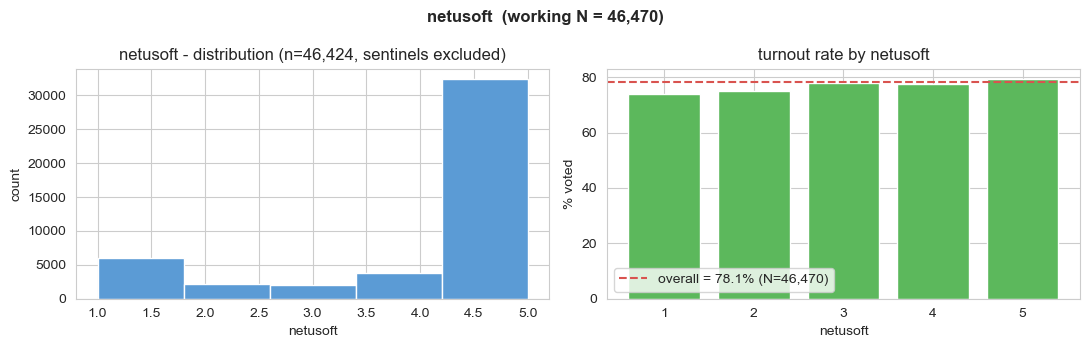

In [79]:
_ = analyze_numeric('netusoft', sentinels=[7, 8, 9])


**Decision:** replace sentinels, mode-impute. Keep raw 1–5.

## 11. Cross-variable correlation (full numeric matrix)

After cleaning sentinels, look at the full correlation structure to confirm there are no surprise multicollinearity issues across categories.


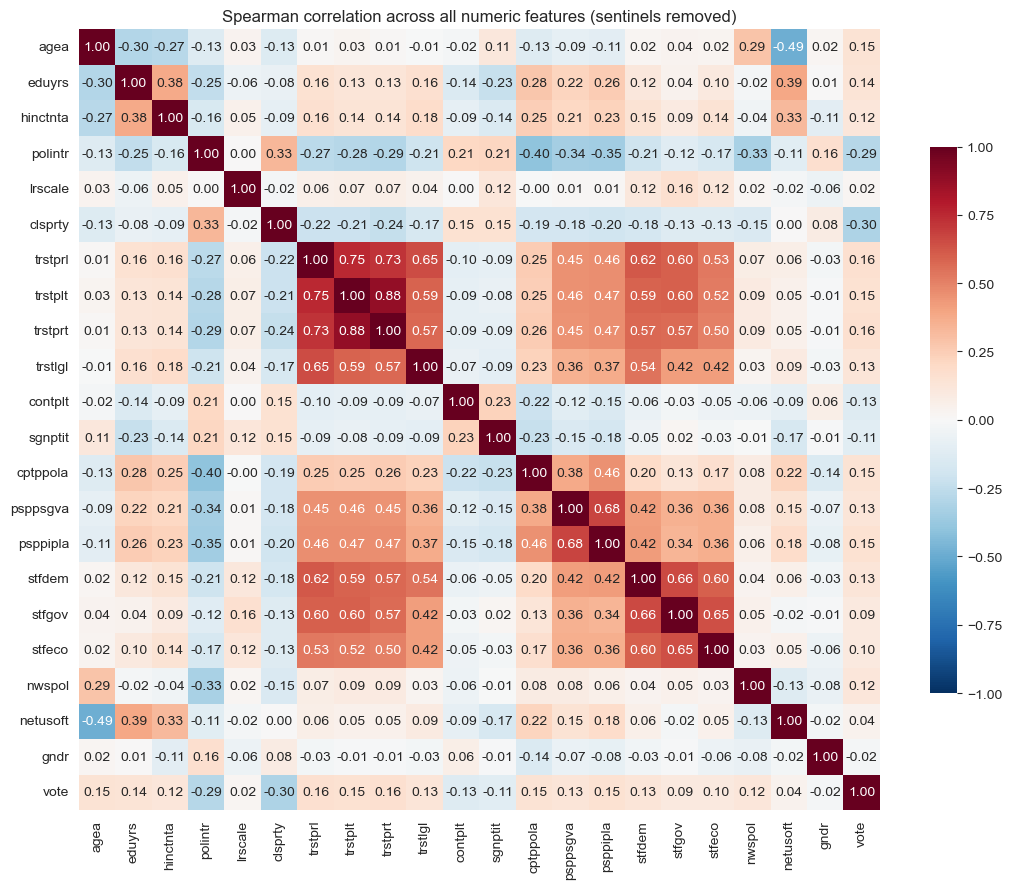

In [80]:
# Build a temporary clean version (sentinels -> NaN, no imputation yet)
sent_map = {
    'agea':[999],'eduyrs':[77,88,99],'hinctnta':[77,88,99],
    'polintr':[7,8,9],'lrscale':[77,88,99],'clsprty':[7,8,9],
    'trstprl':[77,88,99],'trstplt':[77,88,99],'trstprt':[77,88,99],'trstlgl':[77,88,99],
    'contplt':[7,8,9],'sgnptit':[7,8,9],
    'cptppola':[7,8,9],'psppsgva':[7,8,9],'psppipla':[7,8,9],
    'stfdem':[77,88,99],'stfgov':[77,88,99],'stfeco':[77,88,99],
    'nwspol':[6666,7777,8888,9999],'netusoft':[7,8,9],
    'gndr':[9],
}
tmp = df.copy()
for c, codes in sent_map.items():
    tmp[c] = tmp[c].replace(codes, np.nan)

numeric_cols = list(sent_map.keys()) + ['vote']
corr = tmp[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Spearman correlation across all numeric features (sentinels removed)')
plt.tight_layout()
plt.show()


**What to look for:**
- Trust block (`trstprl`, `trstplt`, `trstprt`, `trstlgl`) should light up at r ≈ 0.7–0.8 → confirms the composite.
- Efficacy block (`cptppola`, `psppsgva`, `psppipla`) should be similar.
- Satisfaction block (`stfdem`, `stfgov`, `stfeco`) should be similar.
- *Cross*-block correlations should be moderate (0.3–0.5) → the categories really are distinct constructs.
- Direct correlations with `vote` indicate which features should matter most.


## 12. Decision summary table

The combined cleaning + transformation plan for every variable.


In [81]:
decisions = pd.DataFrame([
    ['vote',     'target',     '3, 7, 8, 9',   'drop ineligible & non-response',  'binary 0/1'],
    ['agea',     'continuous', '999',          'NaN -> median-impute',            'raw + add age_group bins for plots'],
    ['gndr',     'binary',     '9',            'drop',                            'recode 1->1 (M), 2->0 (F)'],
    ['cntry',    'categorical','-',            'no cleaning',                     'one-hot for LR/NN; ordinal for trees'],
    ['eduyrs',   'continuous', '77, 88, 99',   'NaN -> median-impute, cap p99',   'raw + add edu_level bins for plots'],
    ['hinctnta', 'ordinal 1-10','77, 88, 99',  'NaN -> median-impute (per-country)','raw + add income_tertile for plots; was_missing flag'],
    ['polintr',  'ordinal 1-4','7, 8, 9',      'NaN -> median-impute',            'reverse-code (5 - polintr) so higher = more interest'],
    ['lrscale',  'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'raw + add lr_extreme = |lrscale - 5|'],
    ['clsprty',  'binary',     '7, 8, 9',      'NaN -> mode-impute',              'recode 1->1, 2->0'],
    ['trstprl',  'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: keep raw; Set B: -> trust_index'],
    ['trstplt',  'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: keep raw; Set B: -> trust_index'],
    ['trstprt',  'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: keep raw; Set B: -> trust_index'],
    ['trstlgl',  'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: keep raw; Set B: -> trust_index'],
    ['contplt',  'binary',     '7, 8, 9',      'NaN -> mode-impute',              'recode 1->1, 2->0'],
    ['sgnptit',  'binary',     '7, 8, 9',      'NaN -> mode-impute',              'recode 1->1, 2->0'],
    ['cptppola', 'ordinal 1-5','7, 8, 9',      'NaN -> median-impute',            'Set A: raw; Set B: -> efficacy_index'],
    ['psppsgva', 'ordinal 1-5','7, 8, 9',      'NaN -> median-impute',            'Set A: raw; Set B: -> efficacy_index'],
    ['psppipla', 'ordinal 1-5','7, 8, 9',      'NaN -> median-impute',            'Set A: raw; Set B: -> efficacy_index'],
    ['stfdem',   'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: raw; Set B: -> satisfaction_index'],
    ['stfgov',   'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: raw; Set B: -> satisfaction_index'],
    ['stfeco',   'ordinal 0-10','77, 88, 99',  'NaN -> median-impute',            'Set A: raw; Set B: -> satisfaction_index'],
    ['nwspol',   'continuous', '6666/7777/8888/9999','NaN -> median-impute, cap p99','log1p transform; standardise'],
    ['netusoft', 'ordinal 1-5','7, 8, 9',      'NaN -> mode-impute',              'raw'],
    ['pspwght',  'weight',     '-',            'descriptive only',                'NOT a model feature'],
    ['anweight', 'weight',     '-',            'descriptive only',                'NOT a model feature'],
], columns=['variable', 'type', 'sentinels', 'cleaning', 'transformation / use'])

decisions


,variable,type,sentinels,cleaning,transformation / use
0,vote,target,"3, 7, 8, 9",drop ineligible & non-response,binary 0/1
1,agea,continuous,999,NaN -> median-impute,raw + add age_group bins for plots
2,gndr,binary,9,drop,"recode 1->1 (M), 2->0 (F)"
3,cntry,categorical,-,no cleaning,one-hot for LR/NN; ordinal for trees
4,eduyrs,continuous,"77, 88, 99","NaN -> median-impute, cap p99",raw + add edu_level bins for plots
5,hinctnta,ordinal 1-10,"77, 88, 99",NaN -> median-impute (per-country),raw + add income_tertile for plots; was_missin...
6,polintr,ordinal 1-4,"7, 8, 9",NaN -> median-impute,reverse-code (5 - polintr) so higher = more in...
7,lrscale,ordinal 0-10,"77, 88, 99",NaN -> median-impute,raw + add lr_extreme = |lrscale - 5|
8,clsprty,binary,"7, 8, 9",NaN -> mode-impute,"recode 1->1, 2->0"
9,trstprl,ordinal 0-10,"77, 88, 99",NaN -> median-impute,Set A: keep raw; Set B: -> trust_index


## 13. What's next

The next notebook (`02_preprocessing_andreja.ipynb`) will:

1. Implement the cleaning rules from the table above as a single `clean_ess()` function.
2. Build **Feature Set A** (24 raw cleaned features) and **Feature Set B** (~11 features with composite indices).
3. Save both as `feature_set_A.csv` and `feature_set_B.csv` so the modeling notebook can load them directly.

Then `03_modeling_andreja.ipynb` trains all four models on both feature sets, and `04_results_and_analysis_andreja.ipynb` does feature importance, SHAP, and per-country error analysis.
